In [1]:
import torch, cv2, os
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from natsort import natsorted

import torchvision.transforms as transforms
# import torchvision.transforms.v2 as transforms
# from torchvision import tv_tensors


In [2]:
import yaml

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

In [3]:
def get_image_filepaths(main_path, format):
    
    # Сюда всё запишем
    filepaths = []
    # Итерируемся по всем пациентам
    for address, dirs, files in os.walk(main_path):
        # Все названия внутри каждого пациента
        for name in files:
            # Выбираем нужный формат
            if format in name:
                # Добавляем путь до изображения или маски
                if os.path.exists(os.path.join(address, name)):
                    filepaths.append(os.path.join(address, name))

    # assert len(files) == len(filepaths), f"There're another format of files, .txt, for instance. File is: {filepaths}"
    
    return natsorted(filepaths)

In [4]:

# Restore images to suitable images of opencv style
def ImgForPlot(img):
    # img = np.einsum('ijk->jki', img)
    # img = (127.5*(img+1)).astype(np.uint8)
    try:
        img = img.cpu().detach().numpy()
        return np.transpose(img, (1, 2, 0))
    except:
        print("Already numpy.array")
        return np.transpose(img, (1, 2, 0))

In [5]:
# class LeftCamusDataset(torch.utils.data.Dataset):
#     def __init__(self, 
#                  image_paths:list, 
#                  LA_masks_paths:list, 
#                  # image_size=(512, 512), 
#                  label_smooth=None, 
#                  transforms=None):
#         """ Temporarily Simple image torch.Dataset for images and masks(LV+LA)
#          Current version only for CAMUS dataset. We have 2 path to masks (LV and LA).
#         """
#         self.image_paths = image_paths
#         self.la_paths = LA_masks_paths
#         # self.img_size = image_size
#         self.label_smooth = label_smooth
#         self.transforms = transforms

#     def __getitem__(self, index):
#         """ Тут тупняк в том, что в LV есть ещё 1 датасет (EchoNet), но в нём есть и камус тоже, 
#         поэтому такие костыли """
#         img_path = self.image_paths[index]
#         la_path = self.la_paths[index]
#         # 
#         image = self.load_image(img_path, as_mask=False)
#         masks = self.concat_mask(la_path)
#         # Apply transforms
#         if self.transforms:
#             # image, masks = self.transforms(image, masks)  # It doesn't work, I don't know why
#             image = self.transforms(image)
#             masks = self.transforms(masks)
#         return image, masks
    
#     def __len__(self):
#         return len(self.image_paths)
    
#     def load_image(self, path, as_mask=False):
#         if as_mask:
#             img = cv2.imread(path, 0)
#             if self.label_smooth: img = np.where(img > 0, 1-self.label_smooth, 0.)
#             else: img = np.where(img > 0, 1., 0.)
#         else:
#             img = cv2.imread(path)
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = img / 255
#         return img.astype(np.float32)

#     def concat_mask(self, la_path):
#         """ Load both images and concat them """
#         assert os.path.exists(la_path)
#         # Read LA mask
#         la_mask = self.load_image(la_path, as_mask=True)
#         # Replace path to LV and load mask
#         lv_mask = self.load_image(la_path.replace("echoLA", "echoLV"), as_mask=True)
#         if la_mask.ndim == 2:
#             la_mask = np.expand_dims(la_mask, -1)
#             lv_mask = np.expand_dims(lv_mask, -1)
#         return np.concat([lv_mask, la_mask], axis=-1)

In [5]:
class LeftCamusDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        image_paths: list[str],
        LA_mask_paths: list[str],
        transforms=None,
        label_smooth: float | None = None
    ):
        """
        Args:
          image_paths: list of RGB echo image filepaths.
          LA_mask_paths: list of binary mask paths for LA (will infer LV).
          transforms: torchvision or albumentations to apply to both image & label.
          label_smooth: optional small value to smooth binary masks.
        """
        assert len(image_paths) == len(LA_mask_paths)
        self.image_paths = image_paths
        self.la_paths = LA_mask_paths
        self.transforms = transforms
        self.label_smooth = label_smooth

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1) Load & normalize RGB image
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0  # now (H, W, 3)
        # img = img.transpose(2, 0, 1)  # (3, H, W)

        # 2) Load LA and LV masks, build 2-channel label
        la = cv2.imread(self.la_paths[idx], cv2.IMREAD_GRAYSCALE)
        lv_path = self.la_paths[idx].replace("echoLA", "echoLV")
        lv = cv2.imread(lv_path, cv2.IMREAD_GRAYSCALE)
        # threshold + optional smoothing
        la = (la > 0).astype(np.uint8)
        lv = (lv > 0).astype(np.uint8)
        if self.label_smooth:
            la = np.where(la, 1 - self.label_smooth, 0).astype(np.float32)
            lv = np.where(lv, 1 - self.label_smooth, 0).astype(np.float32)
        # combine: 0=BG,1=LV,2=LA
        label = np.zeros_like(la, dtype=np.uint8)
        label[lv == 1] = 255
        label[la == 1] = 128  # if overlap, LA takes precedence


        # 3) Apply joint transforms (if provided)
        if self.transforms:
            img = self.transforms(img)
            label = self.transforms(label)

        # # 4) To torch tensors
        # img_t = torch.from_numpy(img).permute(2, 0, 1)  # (3,H,W)
        # lbl_t = torch.from_numpy(label).long()          # (H,W)

        return {"pixel_values": img, "labels": label}


In [6]:
train_path = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLA/training"
test_path = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLA/testing"

img_train_paths = get_image_filepaths(os.path.join(train_path, "images"), format='.jpg')
img_test_paths = get_image_filepaths(os.path.join(test_path, "images"), format='.jpg')

msk_train_paths = get_image_filepaths(os.path.join(train_path, "masks"), format='.png')
msk_test_paths = get_image_filepaths(os.path.join(test_path, "masks"), format='.png')

len(img_train_paths), len(msk_test_paths)

(20997, 2235)

In [8]:
data_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224,224)),
    # transforms.Normalize(0.5, 0.5)
])

# data_transform = None

train_dataset = LeftCamusDataset(img_train_paths, msk_train_paths, transforms=data_transform)
test_dataset = LeftCamusDataset(img_test_paths, msk_test_paths, transforms=data_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)

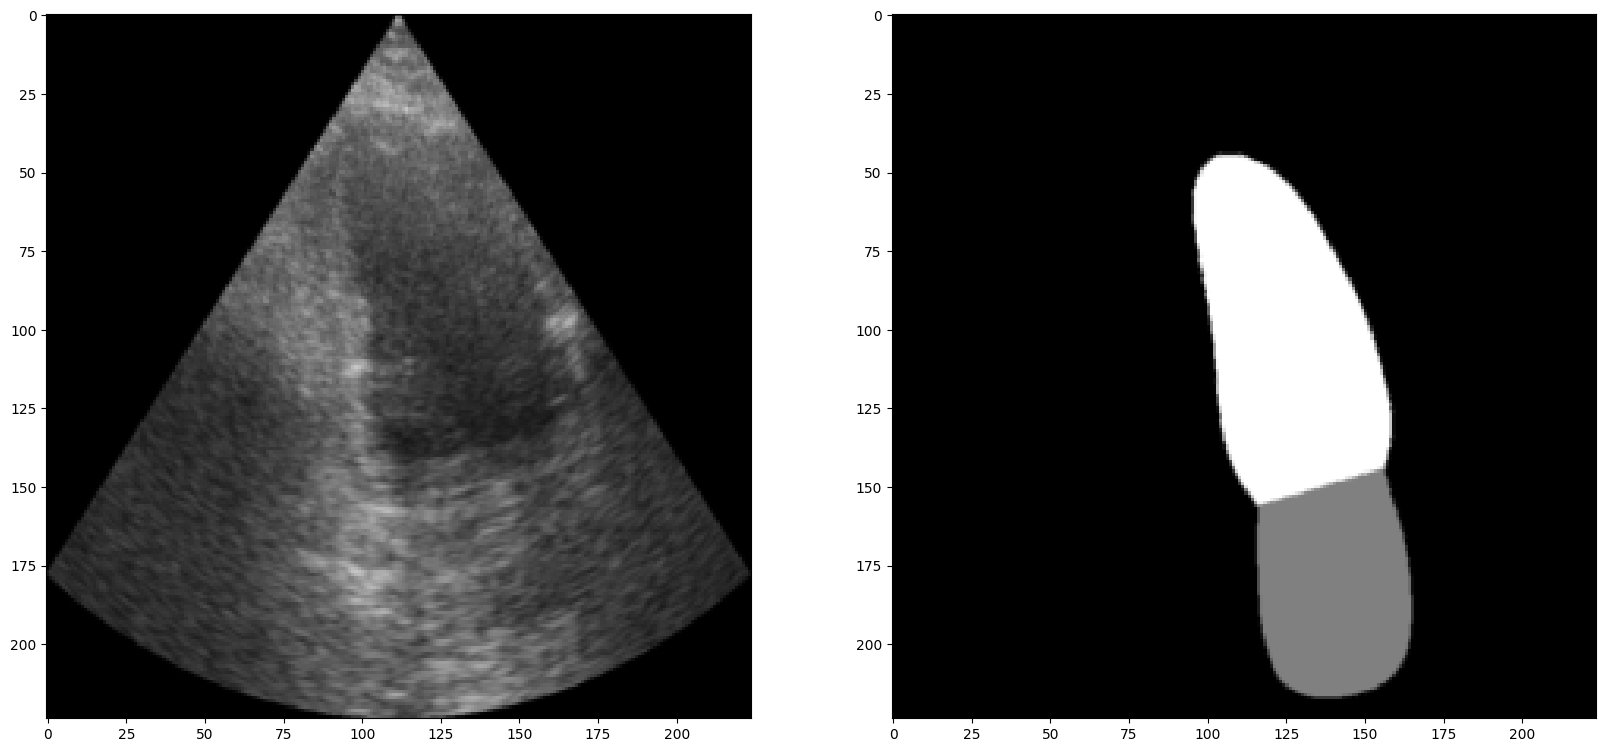

In [9]:
batch = next(iter(test_loader))
fig = plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(ImgForPlot(batch['pixel_values'][0]), 'gray');
plt.subplot(122)
# plt.imshow(ImgForPlot(batch['labels']).sum(axis=-1), 'gray');
plt.imshow(batch['labels'][0].squeeze(0), 'gray');

In [10]:
labels = batch['labels'][0].squeeze(0).cpu().detach().numpy()
torch.unique(batch['labels'], return_counts=True), batch['labels'].shape

((tensor([0.0000e+00, 9.4172e-05, 9.4212e-05,  ..., 1.0000e+00, 1.0000e+00,
          1.0000e+00]),
  tensor([676515,      1,      2,  ...,   7372,  32355,  31747])),
 torch.Size([16, 1, 224, 224]))

In [11]:
batch['pixel_values'][0].shape,  batch['labels'][0].shape

(torch.Size([3, 224, 224]), torch.Size([1, 224, 224]))

## UNETR implementation

https://arxiv.org/pdf/2103.10504

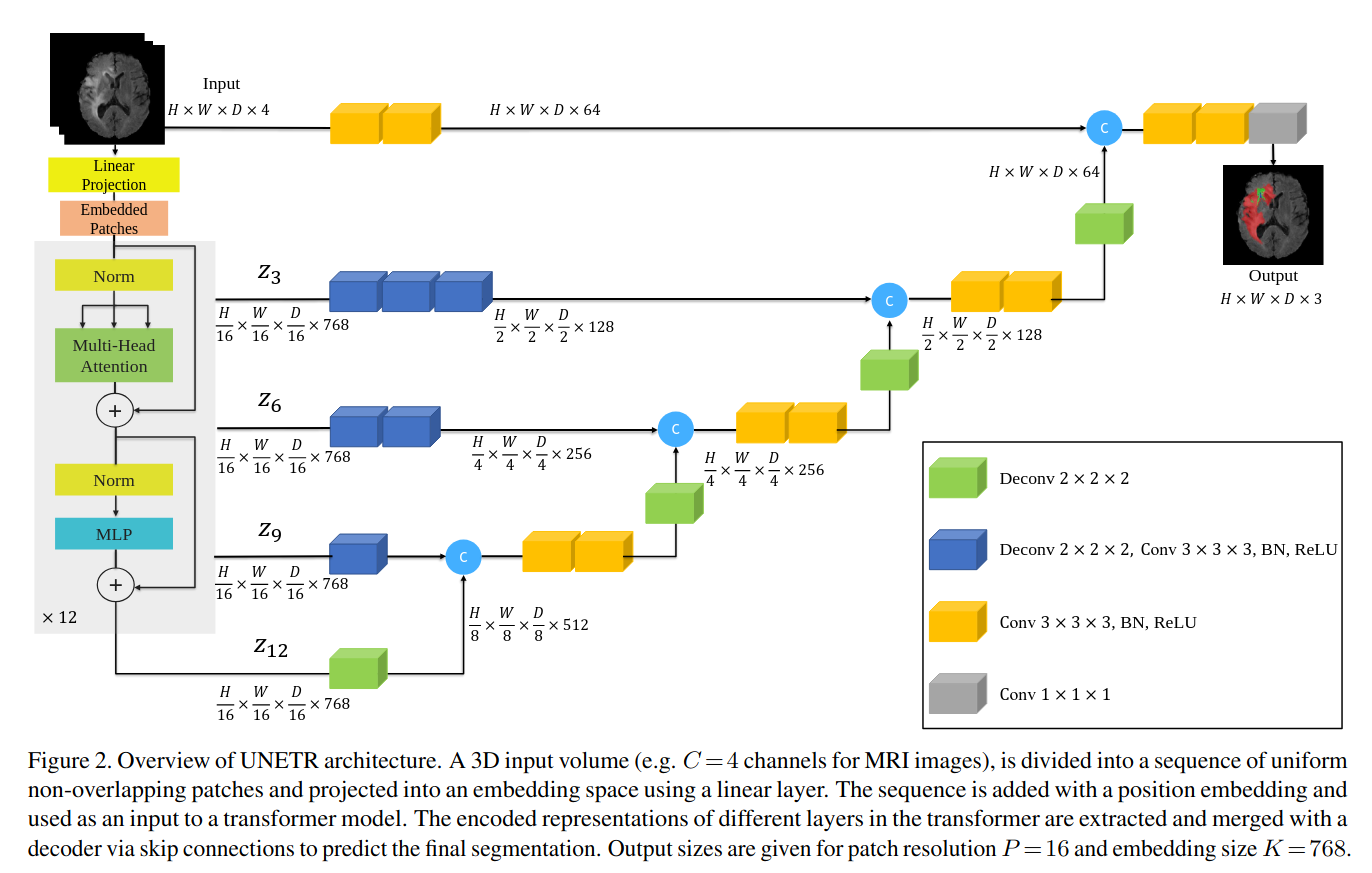

In [7]:
from src.UNETR import UNETR

/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Paths to your MAE config and checkpoint
mae_cfg_path = "models/mae_pretrained/config.json"
mae_ckpt_path = "models/mae_pretrained.pth"  # or .pth

# 1) Instantiate UNETR with MAE weights
model = UNETR(
    mae_config_path=mae_cfg_path,
    mae_checkpoint_path=mae_ckpt_path,
    num_classes=3,
    freeze_encoder_blocks=0
)

# 2) Example forward
x = torch.randn(2, 3, 224, 224)
seg_logits = model(x)  # shape (2, 4, 224, 224)
seg_logits.shape, seg_logits.dtype

Missing keys: ['pooler.dense.weight', 'pooler.dense.bias']
Unexpected keys: []


(torch.Size([2, 3, 224, 224]), torch.float32)

In [9]:
from torchinfo import summary 
summary(model, input_size=(1, 3, 224, 224), depth=3, col_names=["input_size", "output_size", "num_params", "trainable"], row_settings=["var_names"])

Layer (type (var_name))                                                Input Shape               Output Shape              Param #                   Trainable
UNETR (UNETR)                                                          [1, 3, 224, 224]          [1, 3, 224, 224]          --                        Partial
├─ViTModel (encoder)                                                   --                        [1, 197, 768]             --                        Partial
│    └─ViTEmbeddings (embeddings)                                      [1, 3, 224, 224]          [1, 197, 768]             152,064                   Partial
│    │    └─ViTPatchEmbeddings (patch_embeddings)                      [1, 3, 224, 224]          [1, 196, 768]             590,592                   True
│    │    └─Dropout (dropout)                                          [1, 197, 768]             [1, 197, 768]             --                        --
│    └─ViTEncoder (encoder)                                     

In [15]:
out = model(batch['pixel_values'].to('cuda'))
out.shape

torch.Size([16, 2, 224, 224])

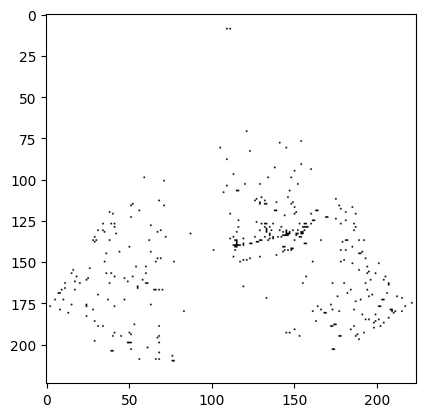

In [16]:
plt.imshow(out[0].argmax(dim=0).cpu().detach().numpy(), 'gray');

In [17]:
enc_out = model.encoder(batch['pixel_values'][0].unsqueeze(0).to('cuda'))
enc_out.last_hidden_state.shape

torch.Size([1, 197, 768])

In [18]:
model._reshape_layer(enc_out.last_hidden_state, 224, 1).shape

torch.Size([1, 768, 14, 14])

In [19]:
def unpatchify_logits_to_image(logits: torch.Tensor, patch_size: int = 16):
    """
    Args:
        logits: torch.Tensor of shape (B, 197, 768)
        patch_size: size of each patch (default 16)
    Returns:
        imgs: torch.Tensor of shape (B, 3, 224, 224)
    """
    B, N, D = logits.shape
    # 1) Drop the CLS token
    #    Remaining tokens = N-1 = 196
    tokens = logits[:, 1:, :]               # shape -> (B, 196, 768)
    
    # 2) Derive grid size (14 x 14) and channels
    num_patches = tokens.shape[1]           # 196
    grid_size = int(num_patches ** 0.5)     # 14
    channels = D // (patch_size * patch_size)  # 768 / 256 = 3

    assert grid_size * grid_size == num_patches, "Expected a square grid of patches"
    assert channels * patch_size * patch_size == D, "Patch dim mismatch"

    # 3) Reshape into (B, grid_h, grid_w, patch_h, patch_w, C)
    x = tokens.view(B, grid_size, grid_size, patch_size, patch_size, channels)
    # 4) Permute to (B, C, grid_h, patch_h, grid_w, patch_w)
    x = x.permute(0, 5, 1, 3, 2, 4)
    # 5) Merge to (B, C, H, W)
    imgs = x.reshape(B, channels, grid_size * patch_size, grid_size * patch_size)
    return imgs

In [20]:
out_img = unpatchify_logits_to_image(torch.sigmoid(enc_out.last_hidden_state), 16)
out_img.shape, out_img.dtype

(torch.Size([1, 3, 224, 224]), torch.float32)

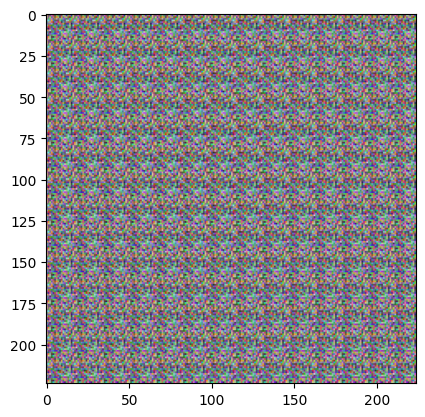

In [21]:
plt.imshow(ImgForPlot(out_img[0]));

In [ ]:
def verify_encoder_loading(encoder: torch.nn.Module, ckpt_path: str):
    """
    Checks that all encoder weights loaded into `encoder` match
    those in the MAE checkpoint at `ckpt_path`. Raises AssertionError
    if any mismatch is found; returns True if all weights match.
    """
    # 1) Load the full checkpoint
    ckpt = torch.load(ckpt_path, map_location="cuda")
    
    # 2) Extract only the encoder portion, stripping "vit." prefix
    mae_encoder_sd = {
        k.replace("vit.", ""): v
        for k, v in ckpt.items()
        if k.startswith("vit.") and not k.startswith("vit.pooler")
    }
    
    # 3) Get the encoder's current state_dict
    enc_sd = encoder.state_dict()
    
    # 4) For each key present in both, compare
    mismatches = []
    for name, param in mae_encoder_sd.items():
        if name not in enc_sd:
            mismatches.append(f"Missing key in encoder: {name}")
            continue
        loaded = enc_sd[name]
        original = param
        if not torch.equal(loaded, original):
            # or torch.allclose(loaded, original) to allow tiny tolerance
            mismatches.append(name)
    
    if mismatches:
        msg = "\n".join([
            "Encoder weight mismatch on the following parameters:"]
            + mismatches
        )
        raise AssertionError(msg)
    
    print("✅ All encoder weights match the checkpoint exactly.")
    return True

# Example usage:
# Assume your UNETR instance is `model` and its encoder is `model.encoder`
verify_encoder_loading(model.encoder, mae_ckpt_path)

✅ All encoder weights match the checkpoint exactly.


True

In [23]:
ckpt = torch.load(mae_ckpt_path, map_location="cpu")
ckpt['vit.encoder.layer.11.attention.attention.query.weight']

tensor([[-0.0072, -0.0279,  0.0369,  ..., -0.0090, -0.0173, -0.0266],
        [-0.0424,  0.0191,  0.0044,  ...,  0.0079,  0.0232,  0.0110],
        [ 0.0029,  0.0072, -0.0042,  ...,  0.0035, -0.0357,  0.0152],
        ...,
        [-0.0155, -0.0088,  0.0358,  ..., -0.0010,  0.0162,  0.0121],
        [-0.0035, -0.0208, -0.0203,  ..., -0.0008, -0.0156, -0.0034],
        [ 0.0195,  0.0245, -0.0145,  ...,  0.0263, -0.0120, -0.0028]])

In [24]:
model.encoder.state_dict()['encoder.layer.11.attention.attention.query.weight']

tensor([[-0.0072, -0.0279,  0.0369,  ..., -0.0090, -0.0173, -0.0266],
        [-0.0424,  0.0191,  0.0044,  ...,  0.0079,  0.0232,  0.0110],
        [ 0.0029,  0.0072, -0.0042,  ...,  0.0035, -0.0357,  0.0152],
        ...,
        [-0.0155, -0.0088,  0.0358,  ..., -0.0010,  0.0162,  0.0121],
        [-0.0035, -0.0208, -0.0203,  ..., -0.0008, -0.0156, -0.0034],
        [ 0.0195,  0.0245, -0.0145,  ...,  0.0263, -0.0120, -0.0028]],
       device='cuda:0')

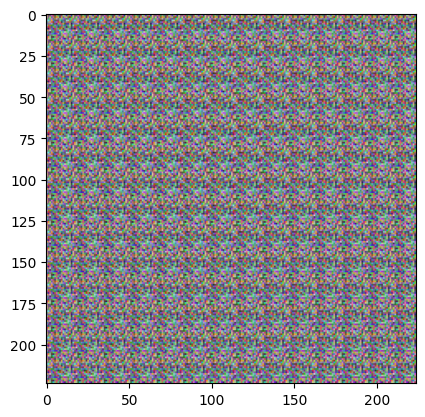

In [25]:
out_img = unpatchify_logits_to_image(torch.sigmoid(enc_out.last_hidden_state), 16)
plt.imshow(ImgForPlot(out_img[0]));

## Training

In [9]:
import torchvision
torch.__version__, torchvision.__version__

('2.6.0+cu124', '0.21.0+cu124')

In [ ]:
import torch.nn as nn
from PIL import Image
import pytorch_lightning as pl # MulticlassDice

# ------------------------- Fixing the Label Pipeline -------------------------
# When using torchvision.transforms.Resize, it interpolates masks as float
# and can produce non-binary values like 0.5. Best practice for masks:
# - Resize using interpolation=InterpolationMode.NEAREST
# - Convert mask to long type with class indices (0, 1)

from torchvision.transforms import InterpolationMode


def mask_to_index(mask_tensor):
    # Input: Tensor (1, H, W) with values in [0, 127, 255]
    # Output: Tensor (H, W) with class indices [0=bg, 1=LA, 2=LV]
    mask = mask_tensor.squeeze(0)
    out = torch.zeros_like(mask, dtype=torch.long)
    out[mask == 127] = 1  # LA
    out[mask == 255] = 2  # LV
    return out

def build_transforms():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224), interpolation=InterpolationMode.BILINEAR),
        transforms.Normalize(0.5, 0.5)
    ])

def build_mask_transform():
    """
    Returns a transform that takes a PIL.Image mask (values {0,127,255})
    and outputs a LongTensor of shape (H, W) with values {0,1,2}.
    """
    return transforms.Compose([
        transforms.ToTensor(),
        # 1) Resize with NEAREST so we keep exact labels
        transforms.Resize((224, 224), interpolation=InterpolationMode.NEAREST),
        # 2)
        transforms.Lambda(lambda x: (x*2).long()),  # map 255 -> 1 (LV), 127 -> 0 (LA)
    ])


In [30]:
from src.datasets import LeftCamusDataset
from src.unetr_model import UNETRModule 

In [31]:
train_dataset = LeftCamusDataset(img_train_paths, 
                                 msk_train_paths, 
                                 img_transforms=build_transforms(), 
                                 msk_transforms=build_mask_transform())
test_dataset = LeftCamusDataset(img_test_paths, 
                                msk_test_paths, 
                                img_transforms=build_transforms(), 
                                msk_transforms=build_mask_transform()
                                )

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=cfg['batch_size'] // 2, shuffle=False)

(tensor([0, 1, 2]), tensor([663169,  54599,  85048]))


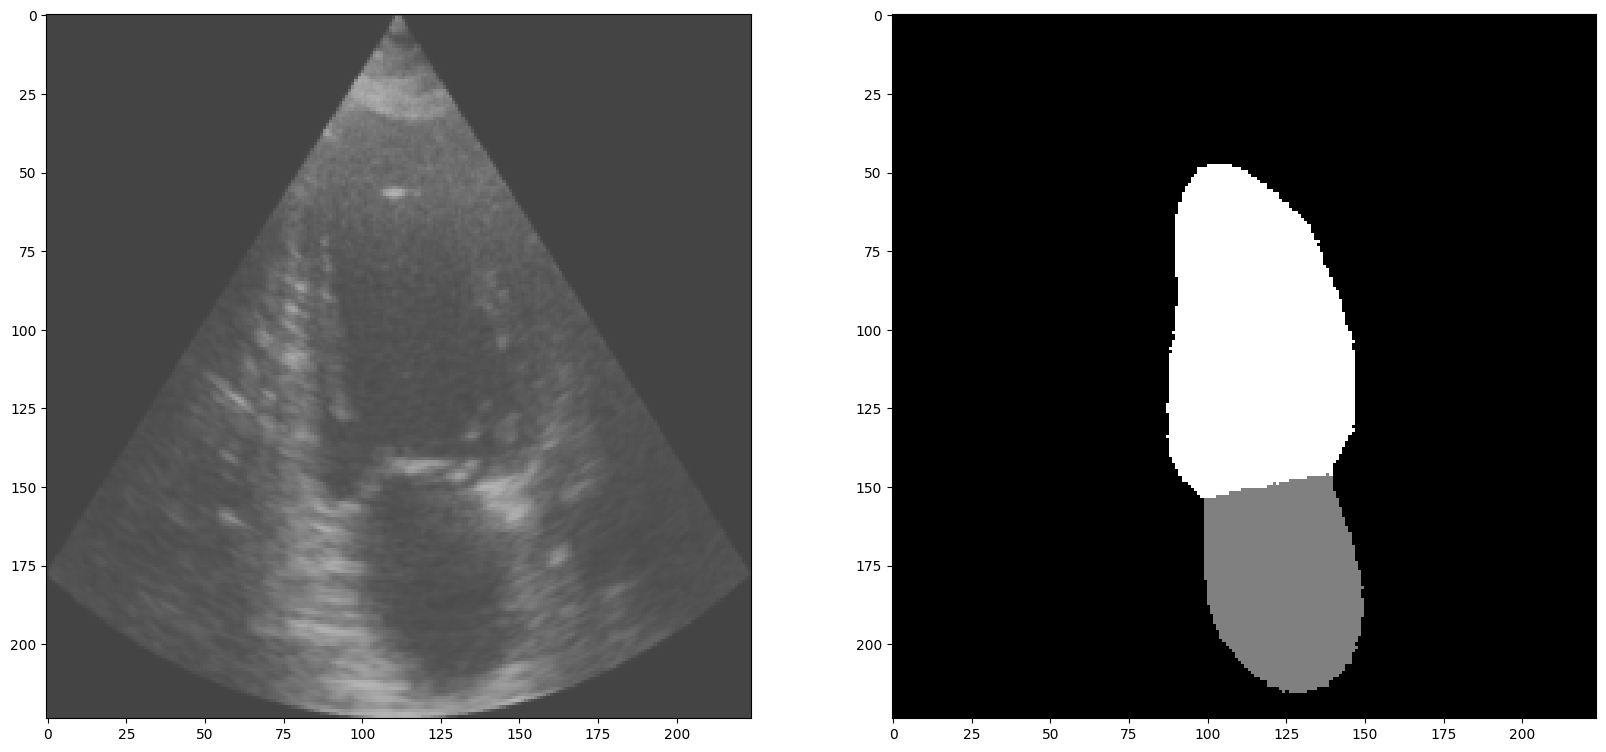

In [32]:
batch = next(iter(test_loader))
print(torch.unique(batch['labels'], return_counts=True))

fig = plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(ImgForPlot(batch['pixel_values'][0].sigmoid()), 'gray');
plt.subplot(122)
# plt.imshow(ImgForPlot(batch['labels']).sum(axis=-1), 'gray');
plt.imshow(batch['labels'][0].squeeze(0), 'gray');



In [33]:
unetr_model = UNETRModule(model=model, lr=cfg['lr'], loss_type=cfg['loss_type'])

trainer = pl.Trainer(
    max_epochs=cfg['epochs'],
    precision=16,        # mixed precision for speed
    accelerator="auto",
    gradient_clip_val=1.0,
    accumulate_grad_batches=5,
)
trainer.fit(unetr_model, train_loader, test_loader)

NameError: name 'pl' is not defined

In [34]:
import torch.nn.functional as F
from tqdm import tqdm
from torchvision.transforms import InterpolationMode
from torchmetrics.classification import MulticlassJaccardIndex, Dice

from src.datasets import LeftCamusDataset
from src.UNETR import UNETR

In [35]:
def build_transforms():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224), interpolation=InterpolationMode.BILINEAR),
        transforms.Normalize(0.5, 0.5)
    ])

def build_mask_transform():
    """
    Returns a transform that takes a PIL.Image mask (values {0,127,255})
    and outputs a LongTensor of shape (H, W) with values {0,1,2}.
    """
    return transforms.Compose([
        transforms.ToTensor(),
        # 1) Resize with NEAREST so we keep exact labels
        transforms.Resize((224, 224), interpolation=InterpolationMode.NEAREST),
        # 2)
        transforms.Lambda(lambda x: (x*2).long()),  # map 255 -> 1 (LV), 127 -> 0 (LA)
    ])

In [36]:
train_path = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLA/training"
test_path = "/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLA/testing"

img_train_paths = get_image_filepaths(os.path.join(train_path, "images"), format='.jpg')
img_test_paths = get_image_filepaths(os.path.join(test_path, "images"), format='.jpg')

msk_train_paths = get_image_filepaths(os.path.join(train_path, "masks"), format='.png')
msk_test_paths = get_image_filepaths(os.path.join(test_path, "masks"), format='.png')

len(img_train_paths), len(msk_test_paths)

(20997, 2235)

In [37]:
train_dataset = LeftCamusDataset(img_train_paths, 
                                 msk_train_paths, 
                                 img_transforms=build_transforms(), 
                                 msk_transforms=build_mask_transform())
test_dataset = LeftCamusDataset(img_test_paths, 
                                msk_test_paths, 
                                img_transforms=build_transforms(), 
                                msk_transforms=build_mask_transform()
                                )

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cfg['batch_size'] // 2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=cfg['batch_size'] // 2, shuffle=False)

Missing keys: ['pooler.dense.weight', 'pooler.dense.bias']
Unexpected keys: []


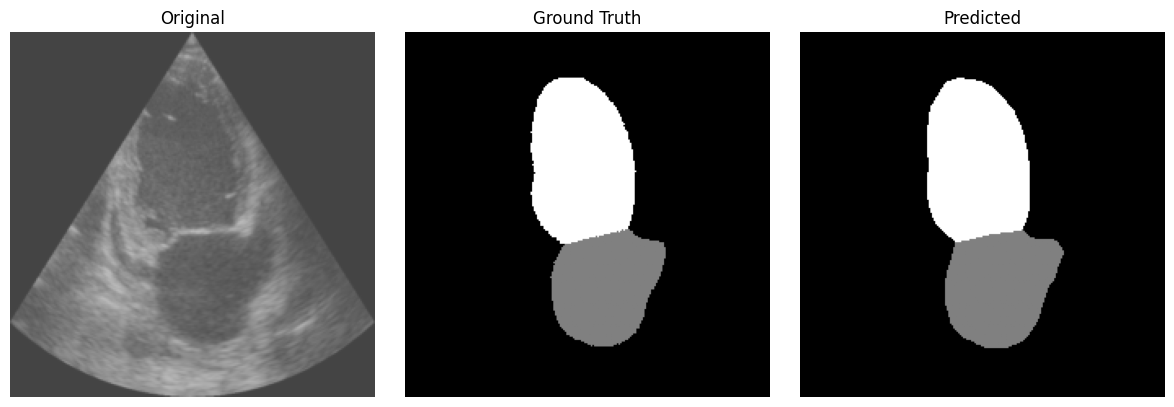

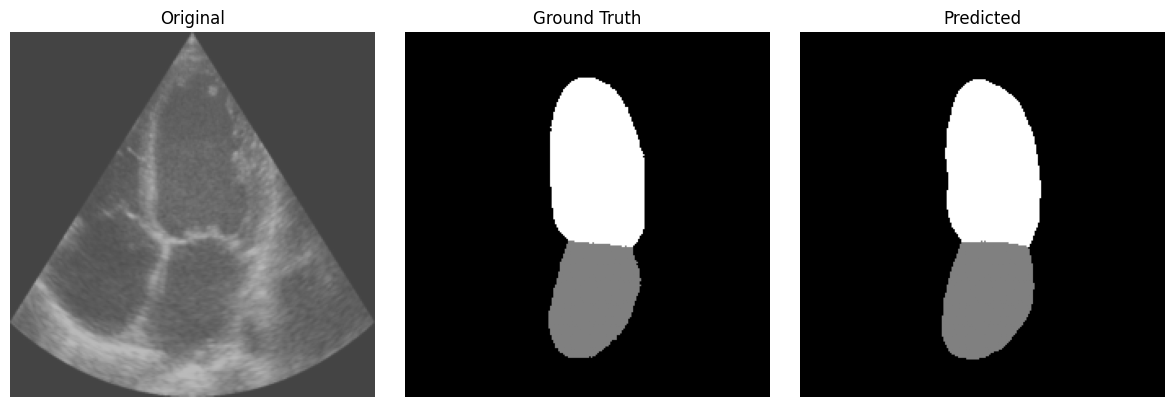

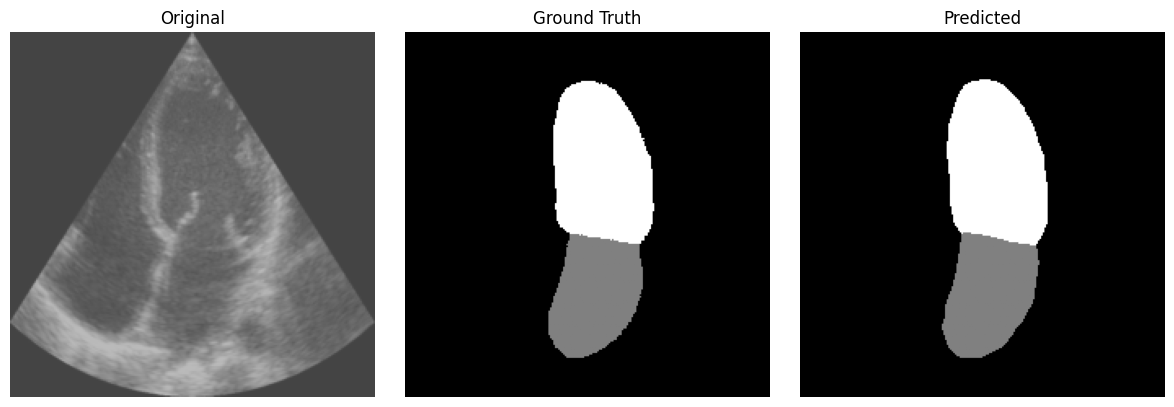

In [38]:
# 1. Define or import your UNETR model class
# from unetr_model import UNETR  # adjust import as needed


# Paths to your MAE config and checkpoint
mae_cfg_path = "models/mae_pretrained/config.json"
mae_ckpt_path = "models/mae_pretrained.pth"  # or .pth
# 2. Load model and weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = UNETR(
    mae_config_path=mae_cfg_path,
    mae_checkpoint_path=mae_ckpt_path,
    num_classes=3,
    freeze_encoder_blocks=0
).to(device)
state_dict = torch.load("models/unetr_model.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

# 3. Get 3 samples from the test loader
# Assume test_loader yields dicts: {"pixel_values": Tensor[B,3,224,224], "labels": Tensor[B,224,224]}
batch = next(iter(test_loader))
images = batch["pixel_values"][-3:].to(device)  # (3,3,224,224)
masks  = batch["labels"][-3:].to(device)        # (3,224,224)

# 4. Run inference
with torch.no_grad():
    logits = model(images)                     # (3,2,224,224)
    preds  = torch.argmax(logits, dim=1)       # (3,224,224)

# 5. Plot side-by-side
def plot_triplet(img, gt_mask, pred_mask, idx):
    img_np = img.sigmoid().cpu().permute(1,2,0).numpy()
    gt_np  = gt_mask.cpu().permute(1,2,0).numpy()
    pr_np  = pred_mask.cpu().numpy()
    fig, axes = plt.subplots(1,3, figsize=(12,4))
    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[1].imshow(gt_np, cmap="gray", vmin=0, vmax=2)
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pr_np, cmap="gray", vmin=0, vmax=2)
    axes[2].set_title("Predicted")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for i in range(3):
    plot_triplet(images[i], masks[i], preds[i], i)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9151381].


Batch Dice: 1.7144, Batch IoU: 0.9849


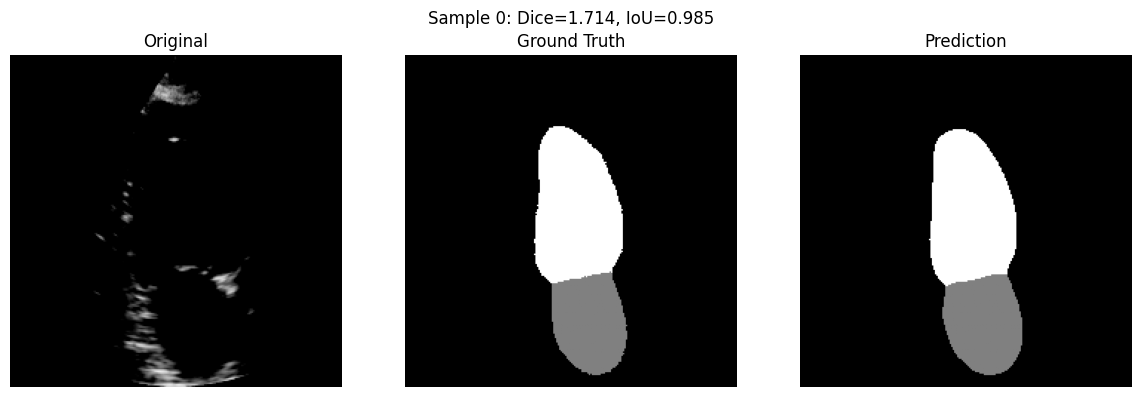

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.95792174].


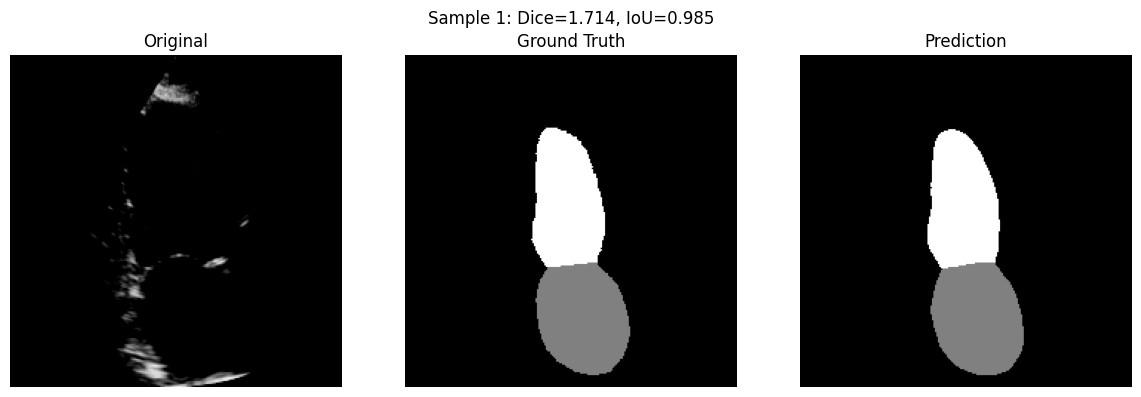

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.927775].


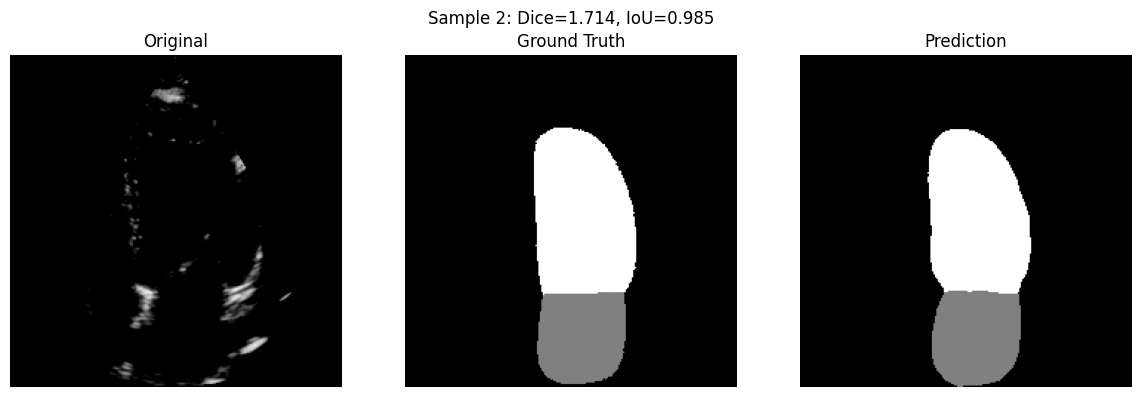

In [ ]:
# 1) Import the segmentation‐specific metrics
from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import JaccardIndex


# 2) Prepare one batch
batch = next(iter(test_loader))
imgs = batch["pixel_values"].to(device)      # (3, 3, 224, 224)
gts  = batch["labels"].squeeze(1).to(device) # (3, 224, 224)

# 3) Inference
with torch.no_grad():
    logits = model(imgs)                     # (3, 3, 224, 224)
    preds  = torch.argmax(logits, dim=1)     # (3, 224, 224)

# 4) Compute metrics in one shot
dice = DiceScore(num_classes=3, average="micro").to(device)   # micro‑averaged Dice :contentReference[oaicite:0]{index=0}
iou  = JaccardIndex(num_classes=3, task="multiclass", average="micro").to(device) # micro‑averaged IoU :contentReference[oaicite:1]{index=1}
# (preds, gts), (preds, gts)

print(f"Batch Dice: {dice.item():.4f}, Batch IoU: {iou.item():.4f}")

# 5) Plot Originals, GT, Predictions
def plot_row(img, gt, pred, idx):
    img_np  = img.cpu().permute(1,2,0).numpy()
    gt_np   = gt.cpu().numpy()
    pr_np   = pred.cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_np);     ax[0].set_title("Original")
    ax[1].imshow(gt_np, cmap="gray", vmin=0, vmax=2); ax[1].set_title("Ground Truth")
    ax[2].imshow(pr_np, cmap="gray", vmin=0, vmax=2); ax[2].set_title("Prediction")
    for a in ax: a.axis("off")
    plt.suptitle(f"Sample {idx}: Dice={dice.item():.3f}, IoU={iou.item():.3f}")
    plt.tight_layout()
    plt.show()

for i in range(3):
    plot_row(imgs[i], gts[i], preds[i], i)

In [51]:
from torchmetrics.classification import Dice


dice_metric = Dice(num_classes=3, average='macro').to(device)

Testing:   0%|          | 0/140 [00:00<?, ?it/s]

Testing: 100%|██████████| 140/140 [00:37<00:00,  3.76it/s]


Test Jaccard (IoU): 0.9663
Test Dice:         1.6739


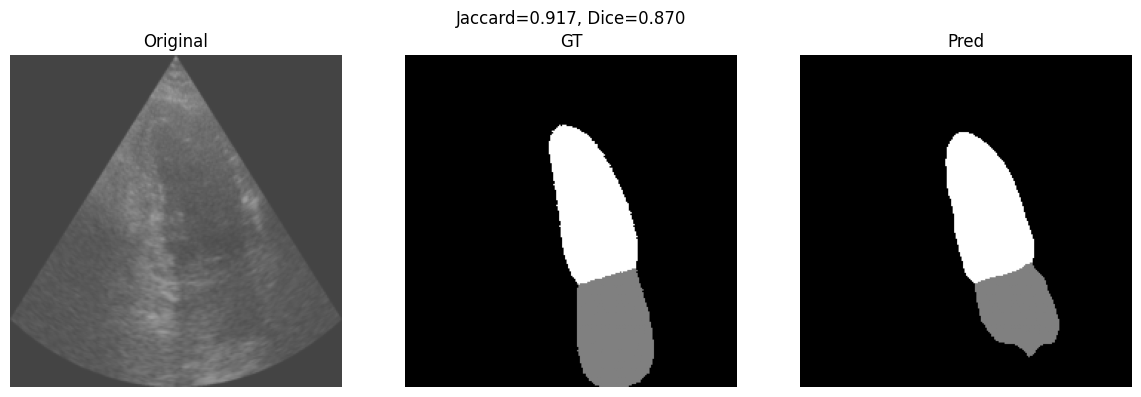

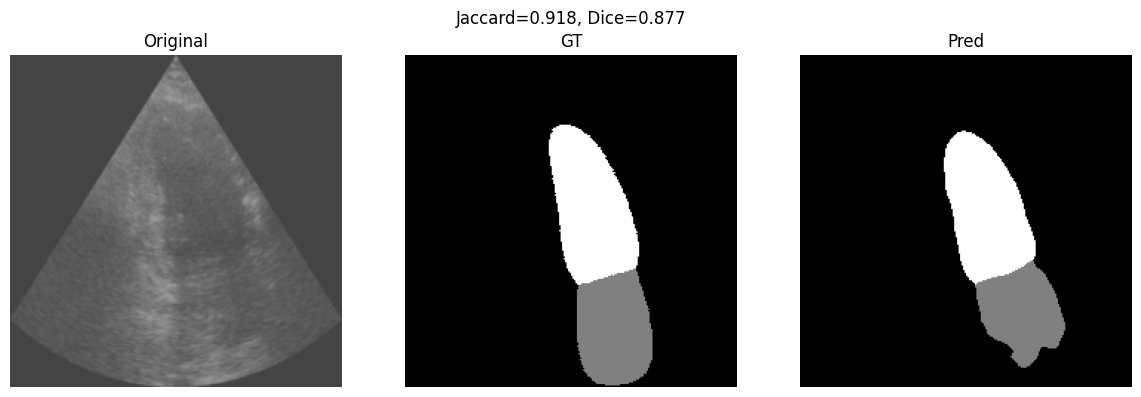

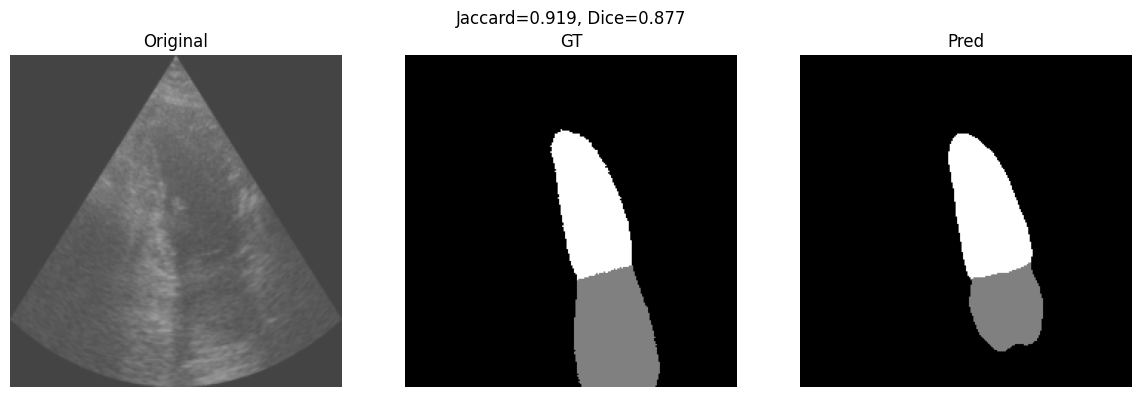

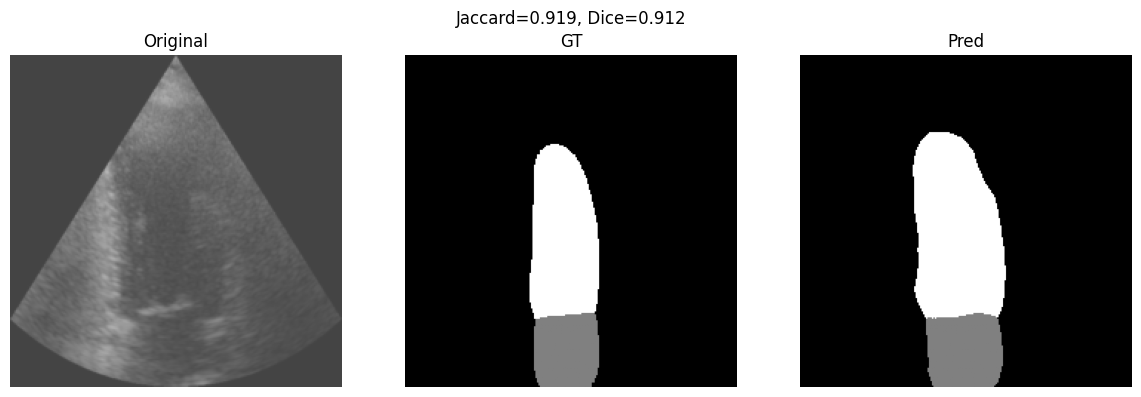

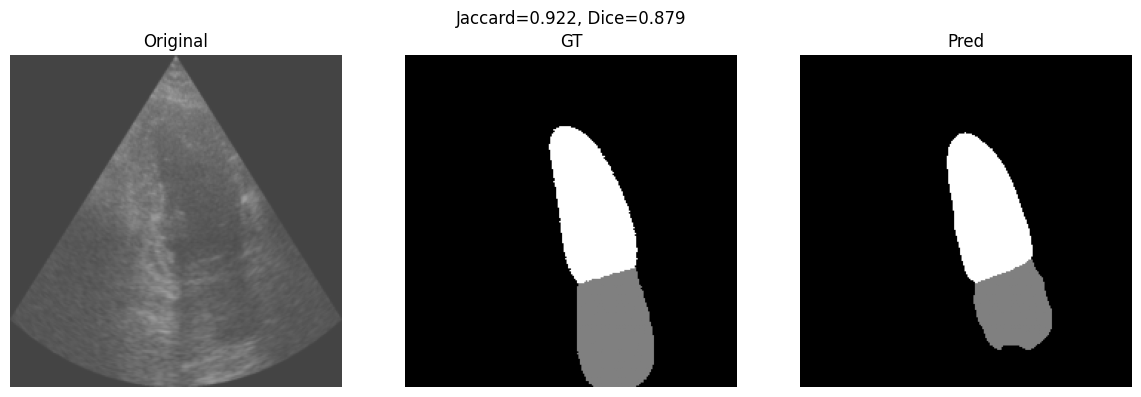

In [52]:
# 4) Compute metrics in one shot
dice = DiceScore(num_classes=3, average="micro").to(device)   # micro‑averaged Dice :contentReference[oaicite:0]{index=0}
iou  = JaccardIndex(num_classes=3, task="multiclass", average="micro").to(device) # micro‑averaged IoU :contentReference[oaicite:1]{index=1}

# 3) Storage for per-sample scores and data (for worst‑n later)
records = []  # list of (jacc, dice, img, gt, pred)

# 4) Full evaluation loop
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        imgs = batch["pixel_values"].to(device)      # (B,3,H,W)
        gts  = batch["labels"].squeeze(1).to(device) # (B,H,W)

        logits = model(imgs)                         # (B,3,H,W)
        preds  = torch.argmax(logits, dim=1)         # (B,H,W)

        # 4a) Update global metrics
        iou.update(preds, gts)
        dice.update(preds, gts)

        # 4b) Compute per-sample
        for i in range(imgs.size(0)):
            jc = iou(
                preds[i].unsqueeze(0),
                gts[i].unsqueeze(0)
            ).item()
            dc = dice_metric(   # dice
                preds[i].unsqueeze(0),
                gts[i].unsqueeze(0)
            )# .item()
            records.append((
                jc, dc,
                imgs[i].cpu(),    # keep image for later
                gts[i].cpu(),
                preds[i].cpu()
            ))

# 5) Compute and print aggregate metrics
mean_jaccard = iou.compute().item()
mean_dice    = dice.compute().item()
print(f"Test Jaccard (IoU): {mean_jaccard:.4f}")
print(f"Test Dice:         {mean_dice:.4f}")

# 6) Visualize the worst-N by Jaccard
worst_n = 5
records.sort(key=lambda x: x[0])  # sort ascending by Jaccard

def plot_row(img, gt, pred, title=""):
    img_np  = img.sigmoid().permute(1,2,0).numpy()
    gt_np   = gt.numpy()
    pr_np   = pred.numpy()
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(img_np);     ax[0].set_title("Original")
    ax[1].imshow(gt_np, cmap="gray", vmin=0, vmax=2); ax[1].set_title("GT")
    ax[2].imshow(pr_np, cmap="gray", vmin=0, vmax=2); ax[2].set_title("Pred")
    plt.suptitle(title)
    for a in ax: a.axis("off")
    plt.tight_layout()
    plt.show()

for idx in range(worst_n):
    jc, dc, img, gt, pred = records[idx]
    plot_row(img, gt, pred, title=f"Jaccard={jc:.3f}, Dice={dc:.3f}")

1.74